# Perform K-fold and Grid serach on Titanic Dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
# Set visual style for plots
sns.set_theme(style="whitegrid")

In [6]:
# 1. LOAD DATA & FEATURE ENGINEERING
# ==========================================
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)


In [7]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

In [8]:
df["Title"] = df["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
).replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

In [9]:
# Family Features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


In [10]:
# Feature Selection
num_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
cat_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone"]

In [11]:
X = df[num_features + cat_features]
y = df["Survived"]

In [13]:
#2. PREPROCESSING PIPELINES
# ==========================================
num_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

In [14]:
cat_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [15]:
preprocessor = ColumnTransformer(
    [
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)

In [16]:
# Set up Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

In [17]:
# 3. BASELINE K-FOLD CROSS-VALIDATION
# ==========================================
print("==========================================")
print("1. BASELINE K-FOLD CROSS-VALIDATION")
print("==========================================")

1. BASELINE K-FOLD CROSS-VALIDATION


In [18]:
baseline_scores = cross_val_score(clf_pipeline, X, y, cv=skf, scoring="accuracy")

for fold_idx, score in enumerate(baseline_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

  Fold 1 Accuracy: 0.8156
  Fold 2 Accuracy: 0.7921
  Fold 3 Accuracy: 0.8202
  Fold 4 Accuracy: 0.8202
  Fold 5 Accuracy: 0.8258


In [19]:
print(
    f"\nMean Baseline Accuracy: {baseline_scores.mean():.4f} (± {baseline_scores.std():.4f})"
)


Mean Baseline Accuracy: 0.8148 (± 0.0118)


In [20]:
# 4. GRID SEARCH HYPERPARAMETER TUNING
# ==========================================
print("\n==========================================")
print("2. GRID SEARCH TUNING")
print("==========================================")


2. GRID SEARCH TUNING


In [21]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 6, 8],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}


In [22]:
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)

In [23]:
grid_search.fit(X, y)
best_model = grid_search.best_estimator_

In [24]:
# Retrieve individual fold scores for the tuned best model
best_model_fold_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][grid_search.best_index_]
    for i in range(5)
]

In [25]:
print("Tuned Best Model Fold Scores:")
for fold_idx, score in enumerate(best_model_fold_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

Tuned Best Model Fold Scores:
  Fold 1 Accuracy: 0.8268
  Fold 2 Accuracy: 0.8315
  Fold 3 Accuracy: 0.8258
  Fold 4 Accuracy: 0.8483
  Fold 5 Accuracy: 0.8596


In [26]:
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print("\nBest Parameters Found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.split('__')[1]}: {val}")


Best Cross-Validation Accuracy: 0.8384

Best Parameters Found:
  max_depth: 8
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100


In [27]:
# Out-of-fold predictions and classification report
y_pred = cross_val_predict(best_model, X, y, cv=skf)

In [28]:
print("\n--- Out-of-Fold Classification Report ---")
print(classification_report(y, y_pred, target_names=["Perished", "Survived"]))



--- Out-of-Fold Classification Report ---
              precision    recall  f1-score   support

    Perished       0.84      0.91      0.87       549
    Survived       0.83      0.73      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.82       891
weighted avg       0.84      0.84      0.84       891



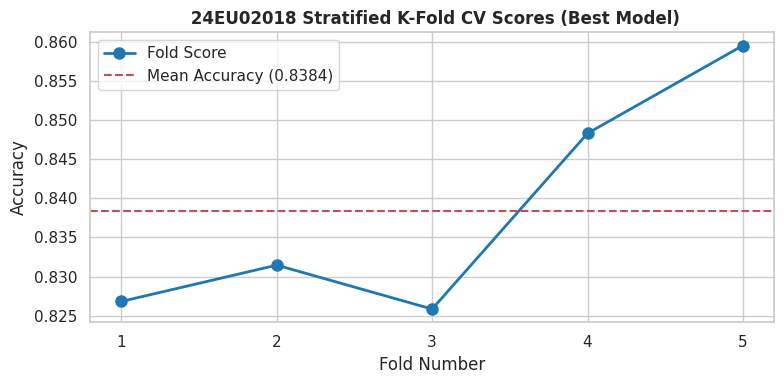

In [29]:
# 5. VISUALIZATIONS
# ==========================================

# Figure 1: Stratified K-Fold Accuracy Scores Across Folds
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, 6),
    best_model_fold_scores,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#1f77b4",
    label="Fold Score",
)
plt.axhline(
    y=np.mean(best_model_fold_scores),
    color="r",
    linestyle="--",
    label=f"Mean Accuracy ({np.mean(best_model_fold_scores):.4f})",
)
plt.title(
    " 24EU02018 Stratified K-Fold CV Scores (Best Model)", fontsize=12, fontweight="bold"
)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

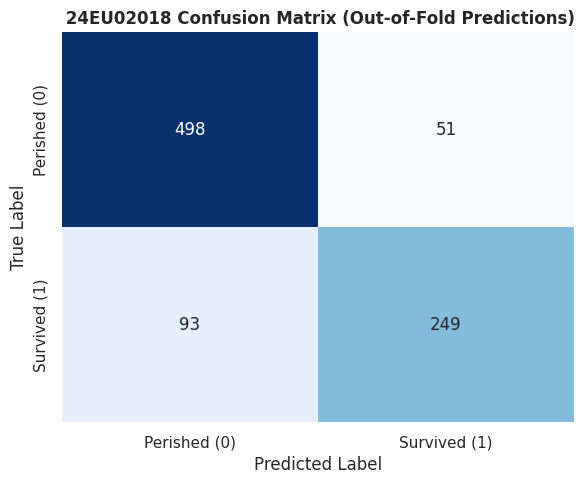

In [30]:
# Figure 2: Confusion Matrix Heatmap
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Perished (0)", "Survived (1)"],
    yticklabels=["Perished (0)", "Survived (1)"],
)
plt.title(
    " 24EU02018 Confusion Matrix (Out-of-Fold Predictions)", fontsize=12, fontweight="bold"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1343/3663352686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


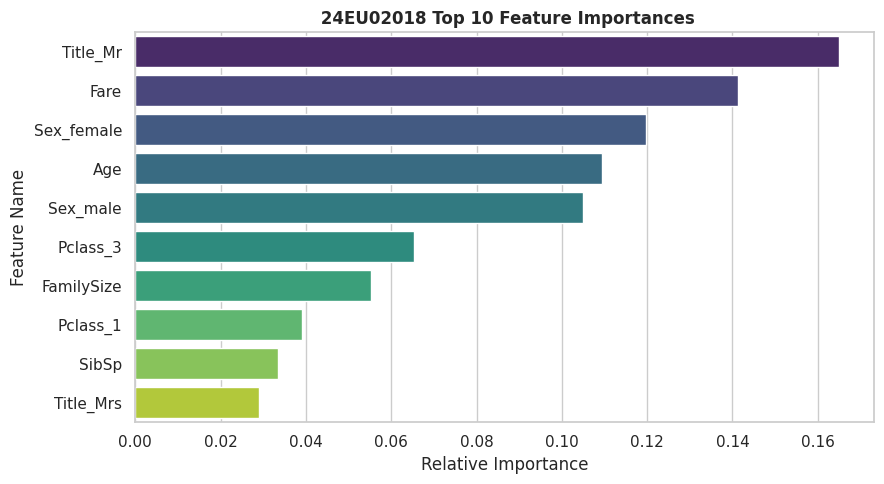

In [31]:
# Figure 3: Top Feature Importances
encoded_cat_cols = (
    best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
)
feature_names = num_features + list(encoded_cat_cols)
importances = best_model.named_steps["classifier"].feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title(" 24EU02018 Top 10 Feature Importances", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()